# Week 6 - Dynamic Programming: Policy Iteration

This notebook evaluates a random deterministic policy, improves it greedily, and repeats until the policy becomes stable.

## Imports and Setup

The next cell imports the existing `src` modules, reloads the plotting module from disk so the latest helper functions are available, and prepares the output directory for Week 6 figures.

In [9]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np

from src.gridworld.environment import GridworldMDP
from src.gridworld.policy_evaluation import iterative_policy_evaluation, values_to_grid
from src.gridworld.policy_iteration import (
    DeterministicPolicy,
    extract_greedy_trajectory,
    initialize_random_deterministic_policy,
    policy_iteration,
)
import src.utils.plotting as plotting

plotting = importlib.reload(plotting)

plot_policy_arrows = plotting.plot_policy_arrows
plot_policy_changes = plotting.plot_policy_changes
plot_policy_comparison = plotting.plot_policy_comparison
plot_trajectory_on_grid = plotting.plot_trajectory_on_grid
plot_value_function_comparison = plotting.plot_value_function_comparison
plot_value_function_grid = plotting.plot_value_function_grid

results_dir = project_root / "results" / "week_06"
results_dir.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
np.set_printoptions(precision=3, suppress=True)

## Initialize the Starting Policy

Week 6 starts from a random deterministic policy. The next cell creates that initial policy and plots its action choice in each valid state.

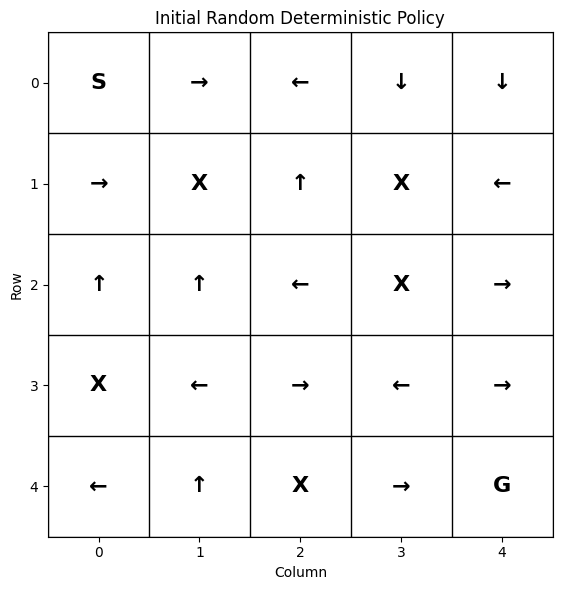

In [10]:
env = GridworldMDP()
initial_policy = initialize_random_deterministic_policy(env=env, seed=42)

plot_policy_arrows(
    initial_policy,
    env,
    title="Initial Random Deterministic Policy",
    save_path=results_dir / "initial_policy_arrows.png",
)

## Evaluate the Initial Policy

Before improving the policy, compute its state-value function with iterative policy evaluation. This gives the baseline values that correspond to the random initial behavior.

In [11]:
initial_values, initial_value_history = iterative_policy_evaluation(
    env=env,
    policy=DeterministicPolicy(initial_policy, env),
    gamma=1.0,
    theta=1e-4,
    max_iterations=1000,
)

initial_value_grid = values_to_grid(initial_values, env)

## Run Policy Iteration

The next cell alternates policy evaluation and greedy policy improvement until the policy stops changing or the iteration limit is reached.

In [12]:
results = policy_iteration(
    env=env,
    gamma=1.0,
    theta=1e-4,
    max_policy_iterations=100,
    max_eval_iterations=1000,
    seed=42,
)

## Inspect the Policy Iteration Output

This cell prints the number of policy-iteration sweeps, whether the policy became stable, how many actions changed per iteration, and the final state-to-action mapping.

In [13]:
print("Number of policy iterations:", results["num_iterations"])
print("Policy stable:", results["policy_stable"])
print("Policy changes:", results["policy_changes"])
print("Final policy:")
for state in sorted(results["final_policy"]):
    print(state, "->", results["final_policy"][state])

Number of policy iterations: 5
Policy stable: True
Policy changes: [13, 8, 3, 3, 0]
Final policy:
(0, 0) -> down
(0, 1) -> right
(0, 2) -> down
(0, 3) -> right
(0, 4) -> down
(1, 0) -> down
(1, 2) -> down
(1, 4) -> down
(2, 0) -> right
(2, 1) -> down
(2, 2) -> down
(2, 4) -> down
(3, 1) -> right
(3, 2) -> right
(3, 3) -> down
(3, 4) -> down
(4, 0) -> right
(4, 1) -> up
(4, 3) -> right


## Plot the Final Value Function

After convergence, convert the final value dictionary into a grid and visualize the final state-value function.

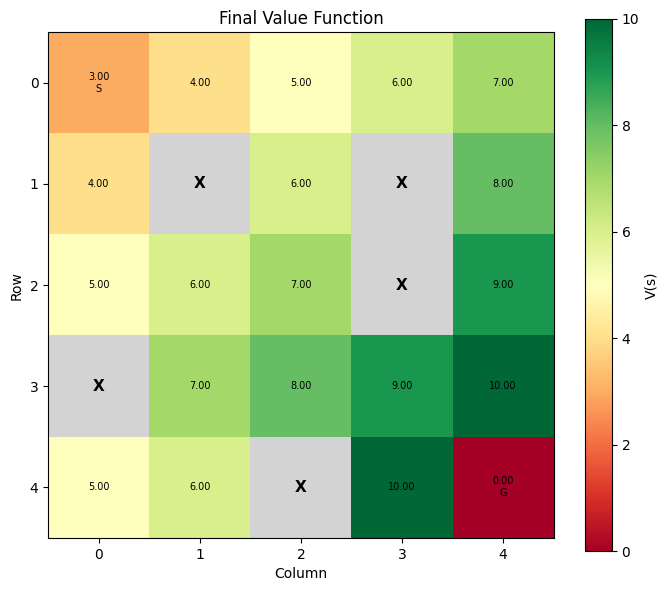

In [14]:
final_value_grid = values_to_grid(results["final_values"], env)

plot_value_function_grid(
    final_value_grid,
    env,
    title="Final Value Function",
    save_path=results_dir / "final_value_function.png",
)

## Compare Initial and Final Values

The next plot places the initial-policy value function and the final-policy value function side by side using the same color scale so the improvement is easy to see.

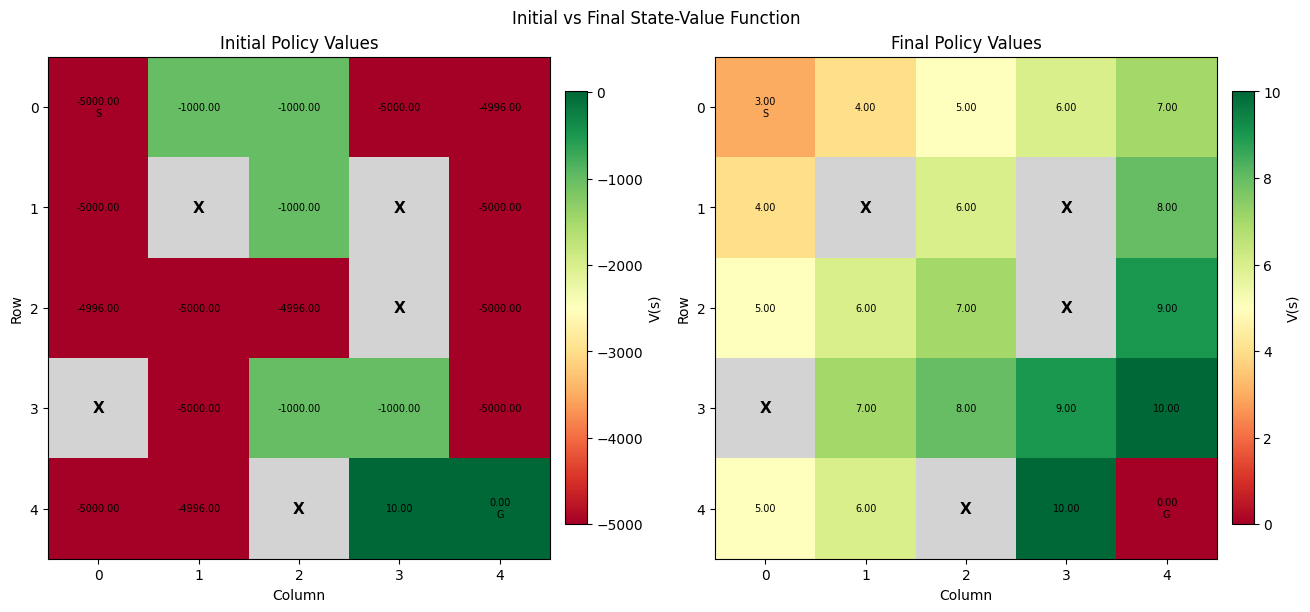

In [15]:
plot_value_function_comparison(
    initial_value_grid,
    final_value_grid,
    env,
    title="Initial vs Final State-Value Function",
    save_path=results_dir / "value_function_comparison.png",
)

## Compare Initial and Final Policies

The next plot compares the initial random policy and the final improved policy directly. In the final panel, states whose actions changed are highlighted.

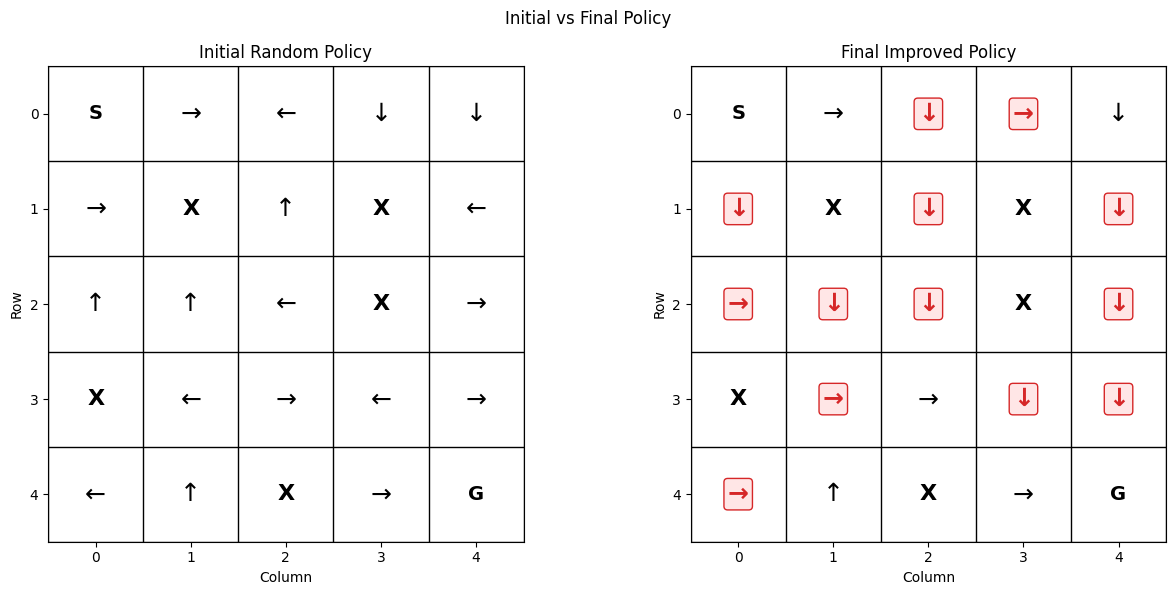

In [16]:
plot_policy_comparison(
    initial_policy,
    results["final_policy"],
    env,
    title="Initial vs Final Policy",
    save_path=results_dir / "policy_comparison.png",
)

## Plot the Final Policy and Policy Changes

These two plots show the final stable policy on its own and the number of states whose actions changed after each improvement step.

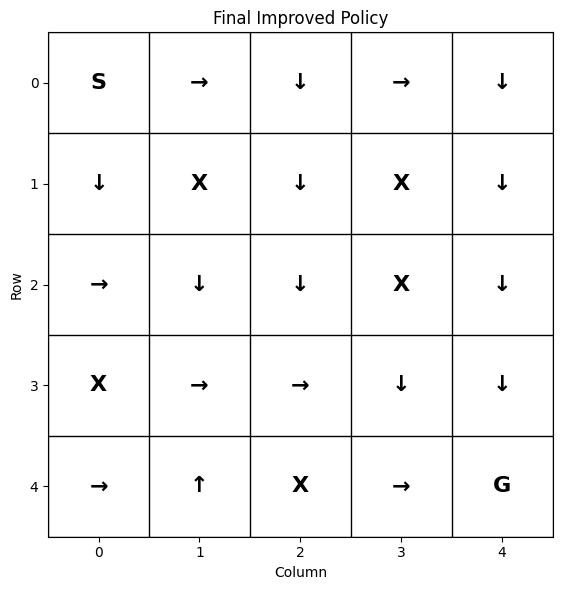

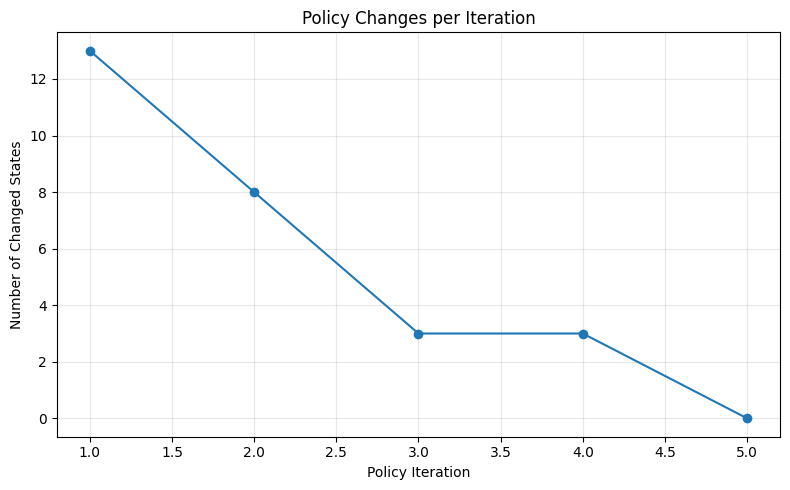

In [17]:
plot_policy_arrows(
    results["final_policy"],
    env,
    title="Final Improved Policy",
    save_path=results_dir / "final_policy_arrows.png",
)

plot_policy_changes(
    results["policy_changes"],
    save_path=results_dir / "policy_changes_per_iteration.png",
)

## Extract a Greedy Trajectory

Once the policy is stable, follow it from the start state to see the concrete path implied by the learned control policy.

In [18]:
trajectory = extract_greedy_trajectory(
    env=env,
    policy=results["final_policy"],
    max_steps=100,
)

trajectory

{'states': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (3, 1),
  (3, 2),
  (3, 3),
  (4, 3),
  (4, 4)],
 'actions': ['down',
  'down',
  'right',
  'down',
  'right',
  'right',
  'down',
  'right'],
 'success': True,
 'episode_length': 8}

## Plot the Final Trajectory

The final visualization overlays the trajectory induced by the stable deterministic policy on the Gridworld.

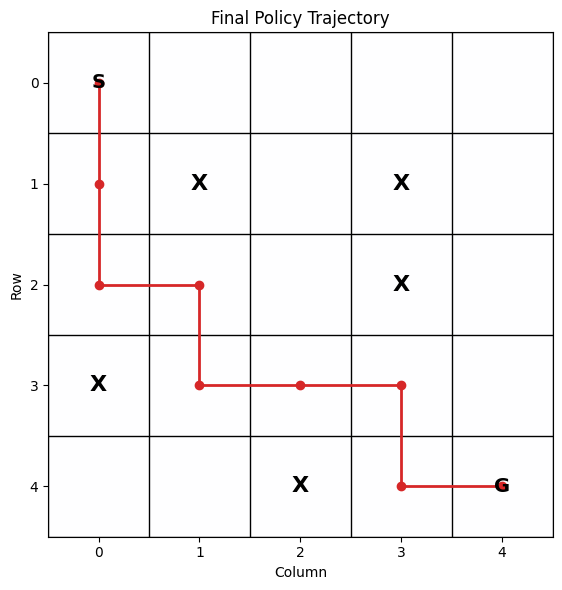

In [19]:
plot_trajectory_on_grid(
    trajectory,
    env,
    title="Final Policy Trajectory",
    save_path=results_dir / "policy_iteration_trajectory.png",
)

## Interpretation

- The initial policy is random and unstructured.
- Policy iteration alternates evaluation and improvement.
- Policy changes decrease over iterations.
- The final policy becomes stable.
- The side-by-side comparison plots make the improvement visible in both values and actions.